In [12]:
#%pip install opencv-python --break-system-packages
#%pip install matplotlib --break-system-packages
#%pip install --upgrade numpy opencv-python matplotlib --break-system-packages
#%pip install pandas --break-system-packages

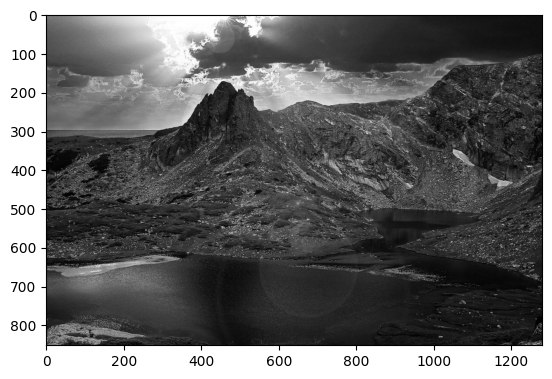

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

%load_ext autoreload
%autoreload 2
import toolbox

img_bgr = cv2.imread('mountain.jpg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
img_gray = img_gray.astype(np.float32)

plt.imshow(img_gray, cmap='gray')
plt.show()

# --- PARTIE I : Test et Validation des Gradients ---

---

Cette section permet de valider la précision des gradients calculés manuellement ($dx$ et $dy$) en les comparant aux versions de référence.

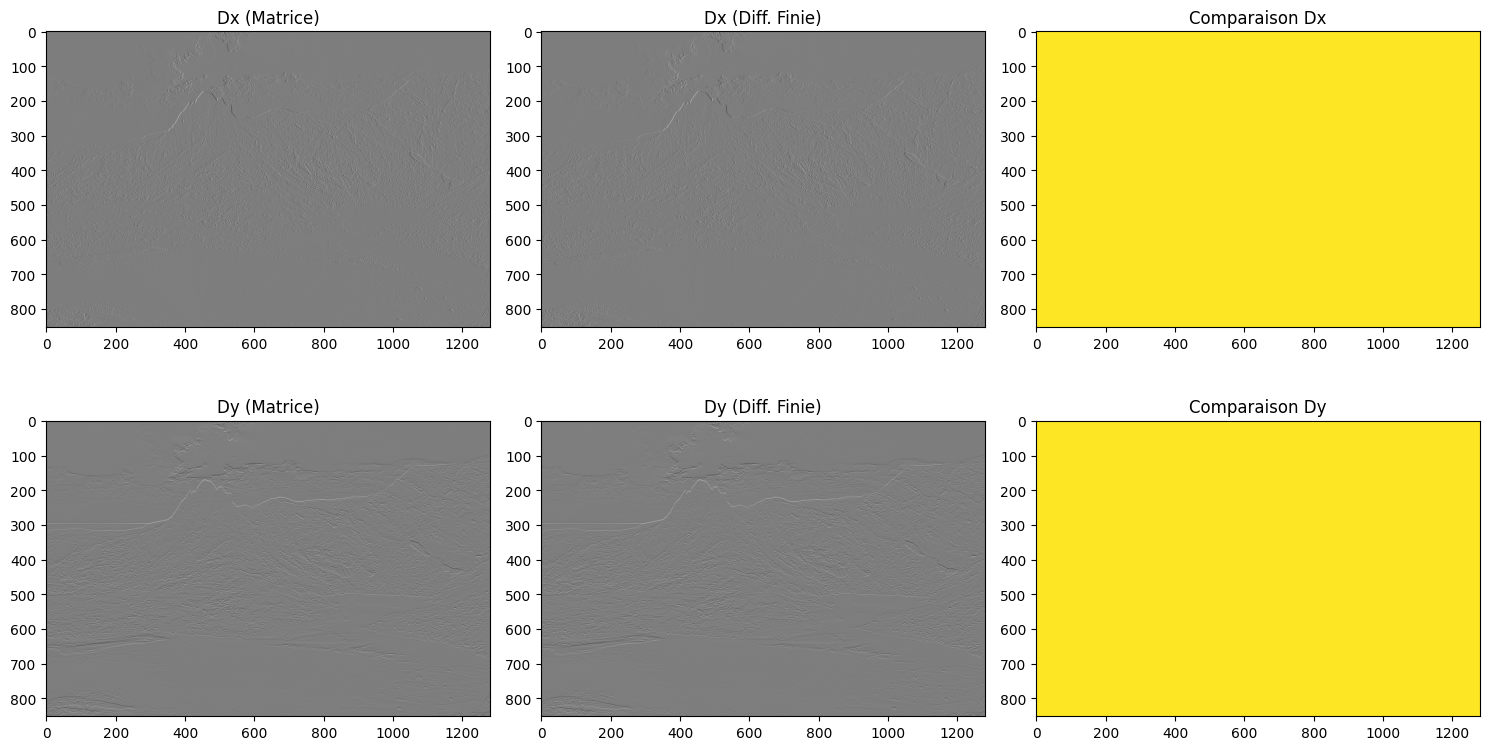

In [3]:
Dx, Dy = toolbox.build_Dx_Dy(img_bgr)
toolbox.comparer_gradients(img_bgr, Dx, Dy)

# --- PARTIE II : Test et Validation de WLS ---

--- 

In [33]:
alpha = 1.5
eps = 1e-4
lamb = 0.5

img_test = cv2.imread('photo_de_test.png')
img_test_rgb = cv2.cvtColor(img_test, cv2.COLOR_BGR2RGB)
img_test_rgb = img_test_rgb.astype(np.float32)/255.0
Dx, Dy = toolbox.build_Dx_Dy(img_test_rgb)

Dx = Dx.tocsr()
Dy = Dy.tocsr()

In [34]:
img_lisse_RGB = toolbox.WLS_RGB(img_test_rgb, Dx, Dy, alpha=1.2, eps=1e-4, lamb=25)

In [35]:
img_lisse_gray = toolbox.WLS_gray(img_test_rgb, Dx, Dy, alpha=1.2, eps=1e-4, lamb=25)

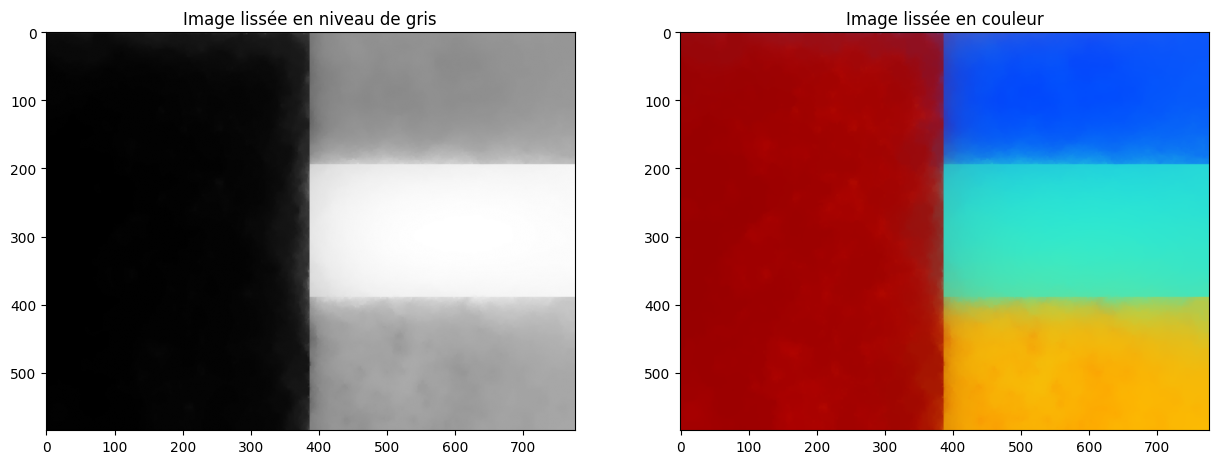

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
axes[0].imshow(img_lisse_gray, cmap='gray')
axes[1].imshow(img_lisse_RGB)
axes[0].set_title("Image lissée en niveau de gris")
axes[1].set_title("Image lissée en couleur")
plt.show()

# --- PARTIE III :  Multi-scale edge-preserving decompositions ---

--- 

In [37]:
alpha = 1.5
eps = 1e-4
lamb = 0.5

img_test = cv2.imread('photo_de_test.png')
img_test_rgb = cv2.cvtColor(img_test, cv2.COLOR_BGR2RGB)
img_test_rgb = img_test_rgb.astype(np.float32)/255.0
Dx, Dy = toolbox.build_Dx_Dy(img_test_rgb)

Dx = Dx.tocsr()
Dy = Dy.tocsr()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.146082651947092e-21..1.000034202749705].


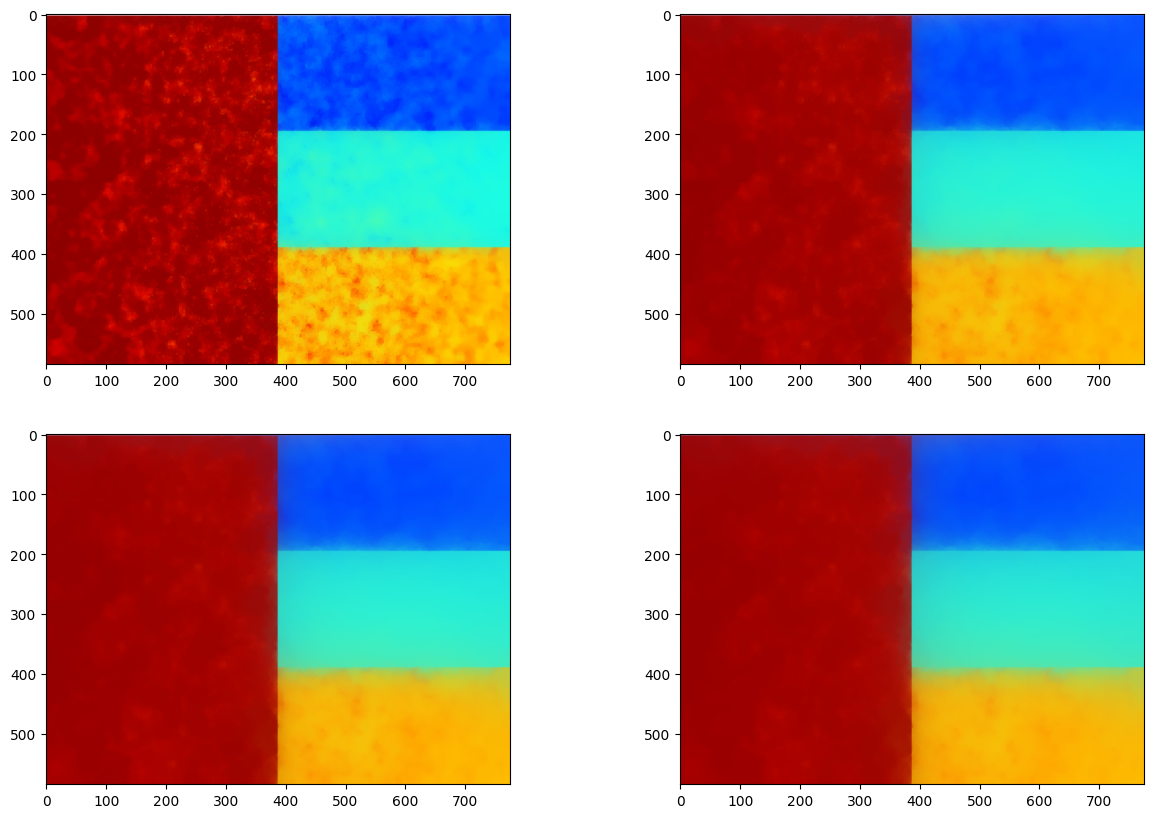

In [39]:
list_lambda = np.linspace(1,20,4)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten() 

for i in range(len(list_lambda)):
    img_lisse_RGB = toolbox.WLS_RGB(img_test_rgb, Dx, Dy, alpha=1.2, eps=1e-4, lamb=list_lambda[i])
    axes[i].imshow(img_lisse_RGB)
    

plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.1460827e-21..1.0000342].


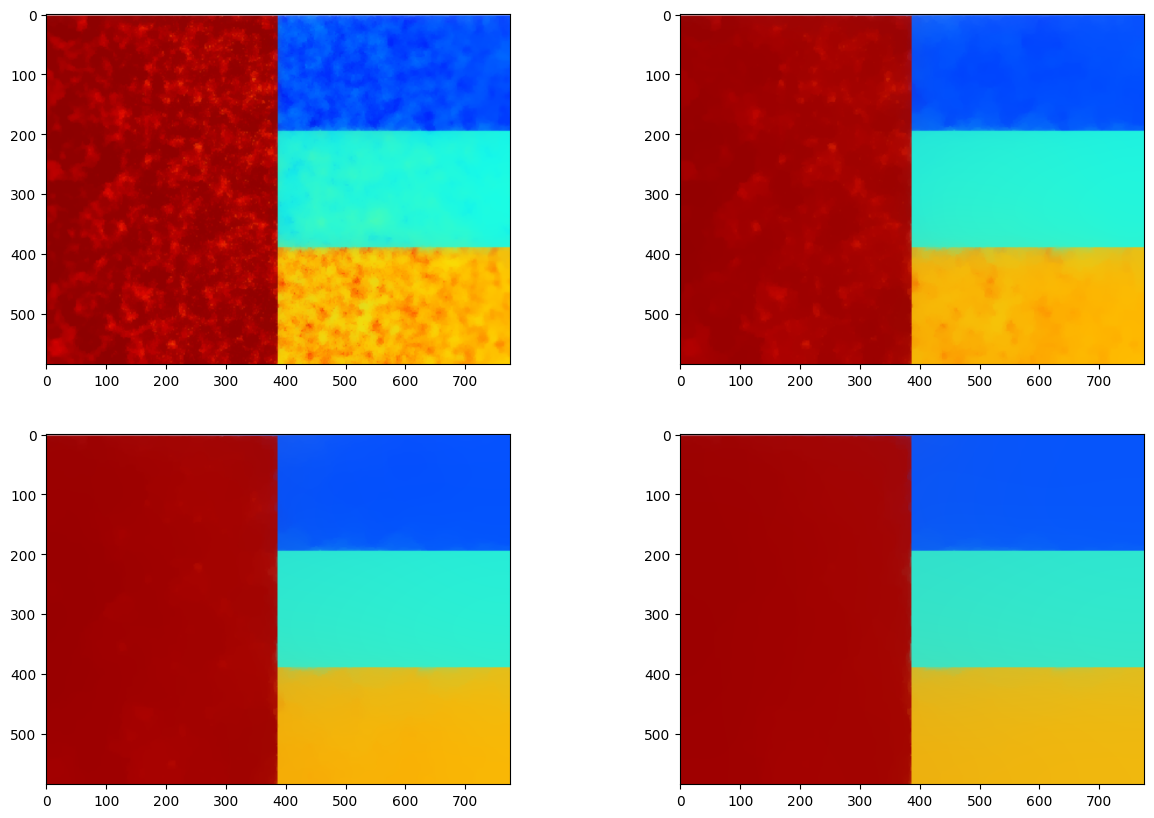

In [40]:
list_lambda = np.linspace(1,2,4)

img_lisse_RGB = toolbox.WLS_RGB(img_test_rgb, Dx, Dy, alpha=1.2, eps=1e-4, lamb=1)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten() 

for i in range(len(list_lambda)):
    img_intermediaire = img_lisse_RGB.copy().astype(np.float32)
    axes[i].imshow(img_intermediaire)
    img_lisse_RGB = toolbox.WLS_RGB(img_intermediaire, Dx, Dy, alpha=1.2, eps=1e-4, lamb=list_lambda[i])
    

plt.show()